# Medical Anomaly Detection on discharge summaries — **Laya** vs **Jev** vs **GPT** (gpt-4o-mini)

## 1. Install & keys

In [1]:
!pip install -q -U laya requests pandas scikit-learn matplotlib openai pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.5/214.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 139.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 142.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 104.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pand

In [2]:
import os, getpass
for k in ["OPENROUTER_API_KEY", "OPENAI_API_KEY"]:
    try:
        from google.colab import userdata
        os.environ[k] = userdata.get(k) or ""
    except Exception:
        pass
    if not os.environ.get(k):
        os.environ[k] = getpass.getpass(f"{k}: ")
OR_KEY  = os.environ["OPENROUTER_API_KEY"]
OR_BASE = "https://openrouter.ai/api/v1"
OAI_KEY = os.environ["OPENAI_API_KEY"]
print("Keys loaded")

Keys loaded


In [3]:
os.environ["USE_TF"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json, math, time
import numpy as np, pandas as pd
from concurrent.futures import ThreadPoolExecutor
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "no GPU (Laya will be ~10x slower)")


torch 2.11.0+cu128 | device: cuda | Tesla T4


## 2. Config

In [4]:
JEV_MODEL   = "typesafe/jev-1.13"     # OpenRouter model id
MAX_WORKERS = 8                       # parallel Jev / GPT calls
N_ROWS      = None                    # cap rows (bounds Jev + GPT cost). None = all

# Laya
LAYA_CHECKPOINT  = "english"          # "english" (512 ctx, strongest on English -> chunked) | "multilingual" (8k ctx, one pass, weaker on English)
CHUNK_WORDS      = 200                # ~300 tokens; clinical text tokenizes densely
CHUNK_OVERLAP    = 40
LAYA_BATCH       = 16
LAYA_NOUL_LABELS = True               # Laya docs: its English checkpoint can follow the literal "true"/"false" noul labels instead of the text;
                                      # the documented workaround shows the model "A"/"B" instead. The returned value is still P(true). Set False to send byte-identical questions.

# Jev
JEV_CHUNK       = False               # False = whole summary in one call (Jev reads long docs). True = same chunking as Laya, for a like-for-like read
JEV_PRICE_PER_M = 0.042               # USD / 1M tokens, fallback only if the API omits usage.cost

# GPT (OpenAI API)
GPT_MODEL       = "gpt-4o-mini"       # any chat model with structured outputs; the logprob variant needs a non-reasoning model
GPT_TEMPERATURE = 0                   # None = provider default
GPT_CHUNK       = False               # False = whole summary in one call (128k ctx). True = same chunking as Laya, for a like-for-like read
GPT_LOGPROB     = True                # also run the 1-token yes/no logprob variant (is_anomaly only; a measured probability instead of a self-reported one)
OPENAI_PRICE    = {"gpt-4o-mini": {"in": 0.15, "out": 0.60}}   # USD / 1M tokens (input, output). Cost is NaN for models missing here

## 3. Shared question design



In [19]:
SEVERITY = {
    "none":     "No clinical concern; expected for this patient.",
    "low":      "Minor deviation; routine follow-up.",
    "moderate": "Clinically relevant; review within hours.",
    "high":     "Serious; prompt clinician review needed.",
    "critical": "Potentially life-threatening; immediate action.",
}
SEV_NAMES = list(SEVERITY)

ANOMALY_TYPES = {
    "none":                        "Safe, appropriate discharge; summary is complete and internally consistent.",
    "unsafe_discharge":            "Patient discharged while clinically unstable or with an unaddressed dangerous finding.",
    "medication_error":            "Discharge medication list has a wrong dose/frequency, dangerous omission, duplication, allergy conflict or contraindication.",
    "documentation_inconsistency": "Summary contradicts itself (side, dates, allergies, diagnoses vs treatment).",
    "missing_follow_up":           "A significant finding or pending result has no follow-up plan or responsible owner.",
}

QUESTIONS = {
    "is_anomaly": {"type": "noul", "instructions":
        "This discharge summary contains a patient-safety problem: unsafe discharge, medication error, "
        "internal contradiction, or a significant finding/pending result without follow-up. "
        "A complete, consistent summary of an appropriate discharge is NOT anomalous. "
        "Values at the patient's documented baseline are NOT anomalous."},
    "anomaly_type": {"type": "choice", "instructions": "Which category best describes this event?",
                     "criteria": ANOMALY_TYPES},
    "severity": {"type": "score", "instructions": "How clinically severe is this event for this patient?",
                 "criteria": [f"{k}: {v}" for k, v in SEVERITY.items()]},
    "urgent_review": {"type": "noul", "instructions":
        "A clinician should act on this discharge summary today (e.g. recall the patient or correct the prescription)."},
}

import copy
LAYA_QUESTIONS = copy.deepcopy(QUESTIONS)
if LAYA_NOUL_LABELS:
    for qq in LAYA_QUESTIONS.values():
        if qq["type"] == "noul":
            qq["labels"] = {"true": "A", "false": "B"}

def as_text(state): return state if isinstance(state, str) else json.dumps(state)
print(json.dumps(QUESTIONS, indent=2)[:700], "...")


{
  "is_anomaly": {
    "type": "noul",
    "instructions": "This discharge summary contains a patient-safety problem: unsafe discharge, medication error, internal contradiction, or a significant finding/pending result without follow-up. A complete, consistent summary of an appropriate discharge is NOT anomalous. Values at the patient's documented baseline are NOT anomalous."
  },
  "anomaly_type": {
    "type": "choice",
    "instructions": "Which category best describes this event?",
    "criteria": {
      "none": "Safe, appropriate discharge; summary is complete and internally consistent.",
      "unsafe_discharge": "Patient discharged while clinically unstable or with an unaddressed dan ...


## 4. Load discharge summaries from CSV



In [6]:
from google.colab import files
print("Upload discharge_summaries.csv (Cancel = use built-in demo set) …")
up = files.upload()
if up: CSV_PATH = next(iter(up))


ds = pd.read_csv(CSV_PATH); SOURCE = CSV_PATH
if "domain" in ds.columns: ds = ds[ds["domain"].astype(str).str.lower() == "discharge"]
low = {c.lower(): c for c in ds.columns}
TEXT_COL  = next((low[c] for c in ["discharge_summary","discharge_text","text","summary","note"] if c in low), None) \
            or ds.select_dtypes("object").apply(lambda s: s.astype(str).str.len().mean()).idxmax()
LABEL_COL = next((low[c] for c in ["label","anomaly","is_anomaly","target"] if c in low), None)
TYPE_COL  = next((low[c] for c in ["exp_type","anomaly_type","type"] if c in low), None)

ds = ds.dropna(subset=[TEXT_COL]).reset_index(drop=True)
if N_ROWS: ds = ds.head(N_ROWS)
HAS_LABELS = LABEL_COL is not None

def case(text, label=None, exp_type=None):
    return {"state": {"discharge_summary": str(text).strip()},
            "label": (1 if str(label).strip().lower() in {"1","true","yes","y","anomaly"} else 0) if label is not None else np.nan,
            "exp_type": (str(exp_type).strip().lower() if exp_type is not None else None)}

CASES = [case(r[TEXT_COL], r[LABEL_COL] if HAS_LABELS else None, r[TYPE_COL] if TYPE_COL else None) for _, r in ds.iterrows()]
cases_df = pd.DataFrame(CASES)
if TYPE_COL:
    bad = set(cases_df.exp_type.dropna()) - set(ANOMALY_TYPES)
    if bad: print("exp_type values not in ANOMALY_TYPES (type accuracy will ignore them):", bad)

print(f"Source: {SOURCE} | cases: {len(CASES)} | text: '{TEXT_COL}' | label: {LABEL_COL} | type: {TYPE_COL}")
if HAS_LABELS: print("anomalies:", int(cases_df.label.sum()), "/", len(cases_df))
print(f"words per summary: mean {ds[TEXT_COL].astype(str).str.split().str.len().mean():.0f}, max {ds[TEXT_COL].astype(str).str.split().str.len().max()}")
print("\nExample summary:\n", CASES[0]["state"]["discharge_summary"][:400], "…")


Upload discharge_summaries.csv (Cancel = use built-in demo set) …


Saving notes.csv to notes.csv
Source: notes.csv | cases: 100 | text: 'note_text' | label: None | type: None
words per summary: mean 77, max 220

Example summary:
 0, 1-IDENTIFY THE CASEES OF ILLNESS BY DOING INVESTIGATIONS 2- TO RELEIVE A known case of DM was presented for follow up AND PT GET IMPROVMENT 3- FOLLOW UP AFTER ONE WEEKS, chief-complaint A known case of DM was presented for follow up - Acanthosis nigricans, Skin Tags --, vital-sign-height 162 cm, There is No History for add mission/Operation, vital-sign-weight, oxygen-saturation 98 %, pulse 100  …


/tmp/ipykernel_828/2676479308.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  or ds.select_dtypes("object").apply(lambda s: s.astype(str).str.len().mean()).idxmax()


## 5. Shared answer parsing



In [7]:
def sev_name(ans):
    probs = ans.get("probabilities")
    if isinstance(probs, dict) and probs:
        try: return SEV_NAMES[int(max(probs, key=probs.get))]
        except Exception: pass
    if isinstance(probs, (list, tuple)) and probs:
        return SEV_NAMES[int(np.argmax(probs))]
    return SEV_NAMES[int(np.clip(round(float(ans.get("score", 0))), 0, len(SEV_NAMES) - 1))]

def aggregate(answer_list):
    p    = [float(a["is_anomaly"]["noul"]) for a in answer_list]
    best = answer_list[int(np.argmax(p))]
    sev  = max(answer_list, key=lambda a: float(a["severity"].get("score", 0)))["severity"]
    return {"p_anomaly": max(p),
            "type": best["anomaly_type"]["choice"],
            "severity": sev_name(sev),
            "severity_score": float(sev.get("score", np.nan)),
            "p_urgent": max(float(a["urgent_review"]["noul"]) for a in answer_list),
            "n_chunks": len(answer_list)}

def chunk_text(text, size=CHUNK_WORDS, overlap=CHUNK_OVERLAP):
    words = text.split()
    if len(words) <= size: return [text]
    chunks, step = [], max(1, size - overlap)
    for start in range(0, len(words), step):
        chunks.append(" ".join(words[start:start + size]))
        if start + size >= len(words): break
    return chunks


## 6. Method A — Laya (local GPU)

In [8]:
import laya

t0 = time.time()
if LAYA_CHECKPOINT == "multilingual":
    agent = laya.load("convaiinnovations/laya", subfolder="multilingual", device=DEVICE)
    agent.cfg["max_len"] = 8192
    CHUNK_WORDS, CHUNK_OVERLAP = 4000, 0
else:
    agent = laya.load("convaiinnovations/laya", device=DEVICE)
print(f"Loaded laya[{LAYA_CHECKPOINT}] on {DEVICE} in {time.time()-t0:.1f}s | max_len {agent.cfg.get('max_len')} | head_max_len {agent.cfg.get('head_max_len')}")

def laya_call(c):
    states = [{"discharge_summary": ch} for ch in chunk_text(c["state"]["discharge_summary"])]
    res = agent.predict_batch(states, LAYA_QUESTIONS, batch_size=LAYA_BATCH)
    out = aggregate([r["answers"] for r in res])
    out.update({"tok_in": sum((r.get("usage") or {}).get("input_tokens", 0) or 0 for r in res), "tok_out": 0, "cost": 0.0})
    return out

demo_laya = agent.predict(CASES[0]["state"], LAYA_QUESTIONS)
print("usage:", demo_laya.get("usage"))
print(json.dumps(demo_laya["answers"], indent=2, default=str)[:2000])
print("\nparsed:", json.dumps(laya_call(CASES[0]), indent=2, default=str))


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/laya/agent.py:1404: RuntimeWarning: laya: this checkpoint ships invalid temperatures or values outside [0.5, 5]; using choice:11+=0.10058280825614929 -> 0.5. Treat confidence from the affected entries as uncalibrated.
  return Agent(model_id_or_path, device=device, token=token, subfolder=subfolder, fast=fast,


Loaded laya[english] on cuda in 20.1s | max_len 512 | head_max_len 192
usage: {'input_tokens': 1492, 'output_tokens': 0}
{
  "is_anomaly": {
    "type": "noul",
    "noul": 0.3616,
    "confidence": 0.6384,
    "answer_confidence": 0.6384,
    "action": {
      "act_probability": 1.0
    }
  },
  "anomaly_type": {
    "type": "choice",
    "choice": "unsafe_discharge",
    "probabilities": {
      "none": 0.2232,
      "unsafe_discharge": 0.2895,
      "medication_error": 0.1417,
      "documentation_inconsistency": 0.134,
      "missing_follow_up": 0.2115
    },
    "confidence": 0.0255,
    "answer_confidence": 0.2895,
    "action": {
      "act_probability": 1.0
    }
  },
  "severity": {
    "type": "score",
    "score": 1.5391,
    "legend": {
      "0": "none: No clinical concern; expected for this patient.",
      "1": "low: Minor deviation; routine follow-up.",
      "2": "moderate: Clinically relevant; review within hours.",
      "3": "high: Serious; prompt clinician review n

## 7. Method B — Jev via OpenRouter's System One API

In [9]:
import requests
_sess = requests.Session()
_sess.headers.update({"Authorization": f"Bearer {OR_KEY}",
                      "Content-Type": "application/json",
                      "X-Title": "Laya vs Jev medical anomaly notebook"})

def jev_raw(state, questions, retries=3):
    for attempt in range(retries):
        r = _sess.post(f"{OR_BASE}/systemone", json={"model": JEV_MODEL, "state": state, "questions": questions}, timeout=60)
        if r.status_code in (429, 500, 502, 503, 529) and attempt < retries - 1:
            time.sleep(2 ** attempt); continue
        if not r.ok:
            raise RuntimeError(f"{r.status_code}: {r.text[:300]}")
        return r.json()

def jev_call(c):
    text = c["state"]["discharge_summary"]
    states = [{"discharge_summary": ch} for ch in chunk_text(text)] if JEV_CHUNK else [c["state"]]
    outs = [jev_raw(s, QUESTIONS) for s in states]
    out = aggregate([d["answers"] for d in outs])
    tok_in = tok_out = 0; cost = 0.0
    for d in outs:
        u = d.get("usage", {}) or {}
        tok_in  += u.get("input_tokens", 0) or 0
        tok_out += u.get("output_tokens", 0) or 0
        cost    += float(u["cost"]) if u.get("cost") is not None else (u.get("input_tokens", 0) or 0) * JEV_PRICE_PER_M / 1e6
    out.update({"tok_in": tok_in, "tok_out": tok_out, "cost": cost})
    return out

demo = jev_raw(CASES[0]["state"], QUESTIONS)
print("served by:", demo.get("model"), "| usage:", demo.get("usage"))
print(json.dumps(demo["answers"], indent=2)[:2000])
print("\nparsed:", json.dumps(jev_call(CASES[0]), indent=2, default=str))


served by: typesafe/jev-1.13-20260917 | usage: {'input_tokens': 938, 'output_tokens': 119, 'cost': 3.9396e-05}
{
  "is_anomaly": {
    "type": "noul",
    "noul": 0.79
  },
  "anomaly_type": {
    "type": "choice",
    "choice": "documentation_inconsistency",
    "probabilities": {
      "medication_error": 0,
      "missing_follow_up": 0.01,
      "none": 0,
      "unsafe_discharge": 0,
      "documentation_inconsistency": 0.99
    },
    "confidence": 0.98
  },
  "severity": {
    "type": "score",
    "score": 0.92,
    "legend": {
      "0": "none: No clinical concern; expected for this patient.",
      "1": "low: Minor deviation; routine follow-up.",
      "2": "moderate: Clinically relevant; review within hours.",
      "3": "high: Serious; prompt clinician review needed.",
      "4": "critical: Potentially life-threatening; immediate action."
    },
    "probabilities": {
      "0": 0.1,
      "1": 0.89,
      "2": 0.01,
      "3": 0,
      "4": 0
    },
    "confidence": 0.9
  }

## 8. Method C — GPT structured output via the OpenAI API

Same four questions as Jev (the `QUESTIONS` text is reused verbatim), rendered as a system prompt + strict JSON schema. The probabilities are self-reported by the model in the JSON, not measured.

In [10]:
from typing import Literal
from pydantic import Field, create_model
from openai import OpenAI

oai    = OpenAI(api_key=OAI_KEY, max_retries=3)
_parse = getattr(oai.chat.completions, "parse", None) or oai.beta.chat.completions.parse
_temp  = {} if GPT_TEMPERATURE is None else {"temperature": GPT_TEMPERATURE}

_types = "\n".join(f"- {k}: {v}" for k, v in ANOMALY_TYPES.items())
_sev   = "\n".join(f"- {k}: {v}" for k, v in SEVERITY.items())
GPT_SYSTEM = ("You are a clinical decision-support classifier. Assess the discharge summary in the state below.\n\n"
              f"is_anomaly_probability: probability (0-1) that: {QUESTIONS['is_anomaly']['instructions']}\n"
              f"anomaly_type: {QUESTIONS['anomaly_type']['instructions']}\n{_types}\n"
              f"severity: {QUESTIONS['severity']['instructions']}\n{_sev}\n"
              f"urgent_review_probability: probability (0-1) that: {QUESTIONS['urgent_review']['instructions']}")

GPT_SCHEMA = create_model("discharge_assessment",
    is_anomaly_probability=(float, Field(ge=0, le=1)),
    anomaly_type=(Literal[tuple(ANOMALY_TYPES)], ...),
    severity=(Literal[tuple(SEV_NAMES)], ...),
    urgent_review_probability=(float, Field(ge=0, le=1)))

def openai_cost(model, usage):
    p = OPENAI_PRICE.get(model, {})
    if p.get("in") is None: return np.nan
    return (usage.prompt_tokens * p["in"] + usage.completion_tokens * (p.get("out") or 0)) / 1e6

def gpt_raw(state):
    comp = _parse(model=GPT_MODEL, response_format=GPT_SCHEMA, **_temp,
                  messages=[{"role": "system", "content": GPT_SYSTEM},
                            {"role": "user", "content": as_text(state)}])
    a = comp.choices[0].message.parsed

    answers = {"is_anomaly":    {"type": "noul",   "noul": float(a.is_anomaly_probability)},
               "anomaly_type":  {"type": "choice", "choice": a.anomaly_type},
               "severity":      {"type": "score",  "score": float(SEV_NAMES.index(a.severity))},
               "urgent_review": {"type": "noul",   "noul": float(a.urgent_review_probability)}}
    return {"answers": answers, "usage": comp.usage, "model": comp.model}

def gpt_call(c):
    text = c["state"]["discharge_summary"]
    states = [{"discharge_summary": ch} for ch in chunk_text(text)] if GPT_CHUNK else [c["state"]]
    outs = [gpt_raw(s) for s in states]
    out = aggregate([d["answers"] for d in outs])
    out.update({"tok_in":  sum(d["usage"].prompt_tokens for d in outs),
                "tok_out": sum(d["usage"].completion_tokens for d in outs),
                "cost":    sum(openai_cost(GPT_MODEL, d["usage"]) for d in outs)})
    return out

demo_gpt = gpt_raw(CASES[0]["state"])
print("served by:", demo_gpt["model"], "| usage:", demo_gpt["usage"].prompt_tokens, "in /", demo_gpt["usage"].completion_tokens, "out")
print(json.dumps(demo_gpt["answers"], indent=2))
print("\nparsed:", json.dumps(gpt_call(CASES[0]), indent=2, default=str))

served by: gpt-4o-mini-2024-07-18 | usage: 718 in / 32 out
{
  "is_anomaly": {
    "type": "noul",
    "noul": 0.8
  },
  "anomaly_type": {
    "type": "choice",
    "choice": "documentation_inconsistency"
  },
  "severity": {
    "type": "score",
    "score": 2.0
  },
  "urgent_review": {
    "type": "noul",
    "noul": 0.7
  }
}

parsed: {
  "p_anomaly": 0.8,
  "type": "documentation_inconsistency",
  "severity": "moderate",
  "severity_score": 2.0,
  "p_urgent": 0.7,
  "n_chunks": 1,
  "tok_in": 718,
  "tok_out": 32,
  "cost": 0.0001269
}


## 9. Method D — GPT logprobs via the OpenAI API (optional, `GPT_LOGPROB`)

One token out (`yes`/`no`); p(anomaly) = P(yes) / (P(yes) + P(no)) from the top-10 logprobs — a measured probability from the same model. Answers `is_anomaly` only, so type / severity are N/A for this method.

In [11]:
def _p_yes(comp):
    lp = comp.choices[0].logprobs
    if not lp or not lp.content:
        raise RuntimeError("no logprobs returned — use a non-reasoning chat model")
    py = pn = 0.0
    for t in lp.content[0].top_logprobs:
        w = t.token.strip().lower()
        if w == "yes": py += math.exp(t.logprob)
        elif w == "no": pn += math.exp(t.logprob)
    return py / (py + pn) if py + pn else np.nan

def gpt_logprob_call(c):
    text = c["state"]["discharge_summary"]
    states = [{"discharge_summary": ch} for ch in chunk_text(text)] if GPT_CHUNK else [c["state"]]
    ps, usage = [], []
    for s in states:
        comp = oai.chat.completions.create(
            model=GPT_MODEL, max_completion_tokens=1, logprobs=True, top_logprobs=10, **_temp,
            messages=[{"role": "system", "content": "You are a clinical decision-support classifier. Answer with exactly one word: yes or no."},
                      {"role": "user", "content": f"State:\n{as_text(s)}\n\nQuestion: {QUESTIONS['is_anomaly']['instructions']} Is this true?"}])
        ps.append(_p_yes(comp)); usage.append(comp.usage)
    return {"p_anomaly": float(np.nanmax(ps)) if np.isfinite(ps).any() else np.nan, "n_chunks": len(states),
            "tok_in": sum(u.prompt_tokens for u in usage), "tok_out": sum(u.completion_tokens for u in usage),
            "cost": sum(openai_cost(GPT_MODEL, u) for u in usage)}

if GPT_LOGPROB:
    print(json.dumps(gpt_logprob_call(CASES[0]), indent=2, default=str))
else:
    print("Skipped: GPT_LOGPROB = False")

{
  "p_anomaly": 0.6792213440023339,
  "n_chunks": 1,
  "tok_in": 379,
  "tok_out": 1,
  "cost": 5.745e-05
}


## 10. Run all methods on every case (per-call timing)


In [12]:
def timed(fn, c):
    t0 = time.perf_counter()
    try:    out, err = fn(c), None
    except Exception as e: out, err = {}, repr(e)[:200]
    return {**out, "latency_ms": (time.perf_counter() - t0) * 1000, "error": err}

METHODS = {"laya": laya_call, "jev": jev_call, "gpt": gpt_call}
if GPT_LOGPROB: METHODS["gpt_logprob"] = gpt_logprob_call
FULL  = [m for m in METHODS if m != "gpt_logprob"]
PAIRS = [(a, b) for i, a in enumerate(FULL) for b in FULL[i + 1:]]
print("methods:", list(METHODS))

frames = []
for name, fn in METHODS.items():
    t0 = time.perf_counter()
    if name == "laya":
        if DEVICE == "cuda": torch.cuda.synchronize()
        res = [timed(fn, c) for c in CASES]
    else:
        with ThreadPoolExecutor(MAX_WORKERS) as ex:
            res = list(ex.map(lambda c: timed(fn, c), CASES))
    print(f"{name:12s} {len(res)} cases in {time.perf_counter()-t0:6.1f}s · errors: {sum(r['error'] is not None for r in res)}"
          + (f" · ≈ ${np.nansum([r.get('cost', np.nan) for r in res]):.5f}" if name != "laya" else ""))
    frames.append(pd.concat([cases_df.drop(columns="state"), pd.DataFrame(res)], axis=1).assign(method=name))

results = pd.concat(frames, ignore_index=True)
errs = results[results.error.notna()]
if len(errs): display(errs[["method", "error"]].head())

methods: ['laya', 'jev', 'gpt', 'gpt_logprob']
laya         100 cases in   10.1s · errors: 0
jev          100 cases in    3.1s · errors: 0 · ≈ $0.00354
gpt          100 cases in    9.3s · errors: 0 · ≈ $0.01108
gpt_logprob  100 cases in    6.2s · errors: 0 · ≈ $0.00421


## 11. Scoreboard

In [13]:
from sklearn.metrics import roc_auc_score, brier_score_loss, precision_recall_fscore_support, accuracy_score

rows = []
for m, g in results.groupby("method", sort=False):
    g = g.dropna(subset=["p_anomaly"])
    row = {"method": m, "n": len(g), "flagged@0.5": int((g.p_anomaly >= 0.5).sum())}
    if HAS_LABELS:
        y, p = g.label.astype(int).values, g.p_anomaly.values
        pr, rc, f1, _ = precision_recall_fscore_support(y, p >= 0.5, average="binary", zero_division=0)
        pos = g[g.label == 1]
        row.update({"accuracy@0.5": accuracy_score(y, p >= 0.5),
                    "ROC-AUC": roc_auc_score(y, p) if len(set(y)) == 2 else np.nan, "Brier ↓": brier_score_loss(y, p),
                    "precision@0.5": pr, "recall@0.5": rc, "F1@0.5": f1})
        if TYPE_COL and g.type.notna().any():
            row["type acc (all)"] = (g.type == g.exp_type).mean()
            row["type acc (anomalies)"] = (pos.type == pos.exp_type).mean() if len(pos) else np.nan
    row.update({"latency p50 ms": g.latency_ms.median(), "latency p90 ms": g.latency_ms.quantile(.9),
                "tokens/call": (g.tok_in + g.tok_out).mean(), "$ per 1k calls": 1000 * g.cost.mean()})
    rows.append(row)
score = pd.DataFrame(rows).set_index("method").reindex(list(METHODS))
display(score.round(4).T)

wide = results.pivot_table(index=results.groupby("method").cumcount(), columns="method", values="p_anomaly")
def agreement(a, b):
    w = wide[[a, b]].dropna()
    return ((w[a] >= .5) == (w[b] >= .5)).mean(), (w[a] - w[b]).abs().mean()

for a, b in PAIRS:
    agr, dp = agreement(a, b)
    print(f"{a} ↔ {b} agreement at 0.5: {agr:.0%} | mean |Δp|: {dp:.3f}")
if GPT_LOGPROB:
    agr, dp = agreement("gpt", "gpt_logprob")
    print(f"gpt ↔ gpt_logprob (same model, self-reported vs measured p): agreement {agr:.0%} | mean |Δp|: {dp:.3f}")
for m in [m for m in METHODS if m != "laya"]:
    print(f"{m} vs Laya on this run: {score.loc[m, 'latency p50 ms'] / score.loc['laya', 'latency p50 ms']:.1f}x the median latency; "
          f"{m} ≈ ${score.loc[m, '$ per 1k calls']:.3f} per 1k calls vs $0 for self-hosted Laya.")
cost_ratio = score.loc["gpt", "$ per 1k calls"] / score.loc["jev", "$ per 1k calls"]
if np.isfinite(cost_ratio): print(f"GPT ({GPT_MODEL}) vs Jev: {cost_ratio:.1f}x the cost per call.")
print("Latency caveat: Laya is a local GPU call; Jev and GPT each include a network round-trip through a different provider (OpenRouter vs OpenAI direct).")
print("The logprob method answers is_anomaly only, so type/severity are N/A. Recall matters most clinically — a missed unsafe discharge costs more than a false alert.")

method,laya,jev,gpt,gpt_logprob
n,100.0000,100.0000,100.0000,100.0000
flagged@0.5,19.0000,98.0000,99.0000,78.0000
latency p50 ms,90.6337,192.0696,680.2553,446.6309
latency p90 ms,129.5310,333.7587,822.1861,570.9195
tokens/call,1098.4700,961.0300,646.6100,277.9600
$ per 1k calls,0.0000,0.0354,0.1108,0.0421


laya ↔ jev agreement at 0.5: 19% | mean |Δp|: 0.544
laya ↔ gpt agreement at 0.5: 18% | mean |Δp|: 0.504
jev ↔ gpt agreement at 0.5: 99% | mean |Δp|: 0.083
gpt ↔ gpt_logprob (same model, self-reported vs measured p): agreement 79% | mean |Δp|: 0.200
jev vs Laya on this run: 2.1x the median latency; jev ≈ $0.035 per 1k calls vs $0 for self-hosted Laya.
gpt vs Laya on this run: 7.5x the median latency; gpt ≈ $0.111 per 1k calls vs $0 for self-hosted Laya.
gpt_logprob vs Laya on this run: 4.9x the median latency; gpt_logprob ≈ $0.042 per 1k calls vs $0 for self-hosted Laya.
GPT (gpt-4o-mini) vs Jev: 3.1x the cost per call.
Latency caveat: Laya is a local GPU call; Jev and GPT each include a network round-trip through a different provider (OpenRouter vs OpenAI direct).
The logprob method answers is_anomaly only, so type/severity are N/A. Recall matters most clinically — a missed unsafe discharge costs more than a false alert.


## 12. Plots: latency, calibration, pairwise agreement

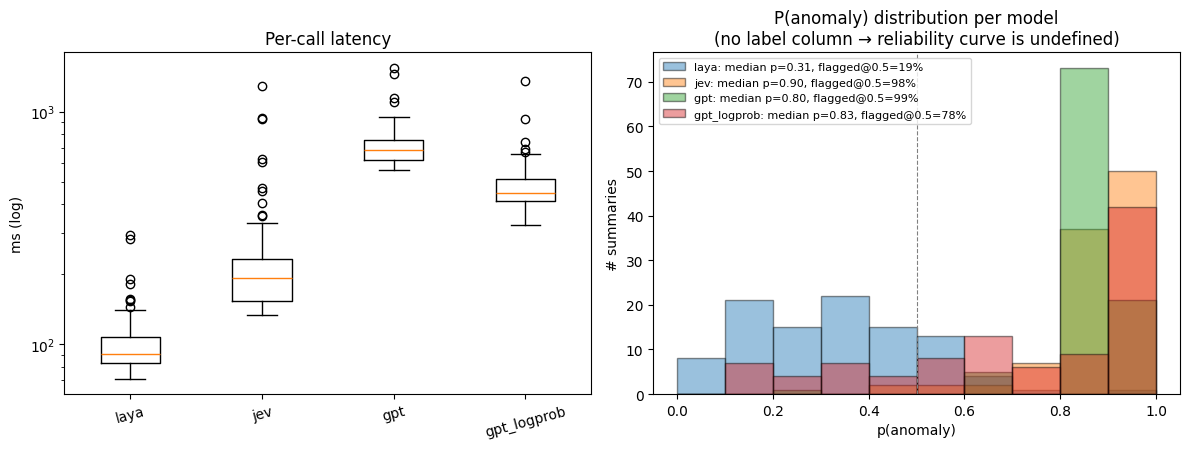

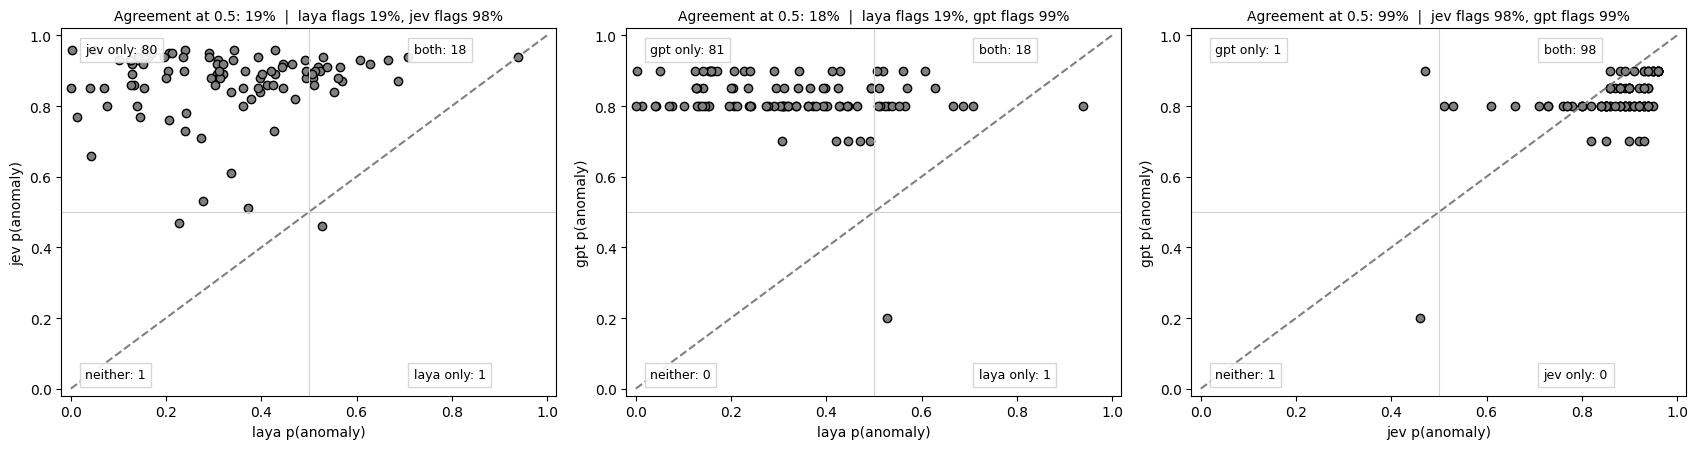

In [14]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

order = list(METHODS)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].boxplot([results[results.method == m].latency_ms.dropna() for m in order])
axes[0].set_xticks(range(1, len(order) + 1))
axes[0].set_xticklabels(order, rotation=15)
axes[0].set_yscale("log")
axes[0].set_ylabel("ms (log)")
axes[0].set_title("Per-call latency")

if HAS_LABELS:
    axes[1].plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
    for m in order:
        g = results[results.method == m].dropna(subset=["p_anomaly"])
        try:
            fp, mp = calibration_curve(g.label.astype(int), g.p_anomaly,
                                       n_bins=min(4, max(2, len(g) // 3)), strategy="quantile")
            axes[1].plot(mp, fp, "o-", label=m)
        except Exception as e:
            print("reliability skipped for", m, ":", e)
    axes[1].set_xlabel("predicted p(anomaly)")
    axes[1].set_ylabel("observed anomaly rate")
    axes[1].set_title("Reliability (noisy at this n)")
else:
    bins = np.linspace(0, 1, 11)
    for m in order:
        p = results[results.method == m].p_anomaly.dropna()
        axes[1].hist(p, bins=bins, alpha=0.45, edgecolor="k",
                     label=f"{m}: median p={p.median():.2f}, flagged@0.5={(p >= .5).mean():.0%}")
    axes[1].axvline(0.5, color="grey", lw=0.8, ls="--")
    axes[1].set_xlabel("p(anomaly)")
    axes[1].set_ylabel("# summaries")
    axes[1].set_title("P(anomaly) distribution per model\n(no label column → reliability curve is undefined)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

def agreement_panel(ax, a, b):
    w = wide[[a, b]].dropna(); x, y = w[a], w[b]
    both   = int(((x >= .5) & (y >= .5)).sum()); none_  = int(((x <  .5) & (y <  .5)).sum())
    b_only = int(((x <  .5) & (y >= .5)).sum()); a_only = int(((x >= .5) & (y <  .5)).sum())
    agr = (both + none_) / max(1, len(w))
    if HAS_LABELS:
        ax.scatter(x, y, c=cases_df.label.reindex(w.index).fillna(0.5).values, cmap="coolwarm", edgecolor="k")
    else:
        ax.scatter(x, y, color="grey", edgecolor="k")
    ax.plot([0, 1], [0, 1], "--", color="grey")
    ax.axhline(.5, color="lightgrey", lw=.8)
    ax.axvline(.5, color="lightgrey", lw=.8)
    for (px, py, txt) in [(.03, .95, f"{b} only: {b_only}"), (.72, .95, f"both: {both}"),
                          (.03, .03, f"neither: {none_}"),   (.72, .03, f"{a} only: {a_only}")]:
        ax.text(px, py, txt, fontsize=9, bbox=dict(fc="white", ec="lightgrey", alpha=.9))
    ax.set_xlim(-.02, 1.02); ax.set_ylim(-.02, 1.02)
    ax.set_xlabel(f"{a} p(anomaly)")
    ax.set_ylabel(f"{b} p(anomaly)")
    ax.set_title(f"Agreement at 0.5: {agr:.0%}  |  {a} flags {(x >= .5).mean():.0%}, {b} flags {(y >= .5).mean():.0%}"
                 + ("\n(red = true anomaly)" if HAS_LABELS else ""), fontsize=10)

fig, axes = plt.subplots(1, len(PAIRS), figsize=(5.7 * len(PAIRS), 4.6))
for ax, (a, b) in zip(np.atleast_1d(axes), PAIRS):
    agreement_panel(ax, a, b)
plt.tight_layout()
plt.show()

## 13. Where do they disagree

In [15]:
cmp = cases_df[["label", "exp_type"]].copy()
cmp["case"] = [as_text(c["state"]["discharge_summary"]).replace("\n", " ")[:140] + "…" for c in CASES]
for m in METHODS:
    sub = results[results.method == m].reset_index(drop=True)
    cmp[f"p_{m}"] = sub.p_anomaly.round(3)
    if m in FULL: cmp[f"type_{m}"] = sub.type; cmp[f"sev_{m}"] = sub.severity

flag = pd.Series(False, index=cmp.index)
for a, b in PAIRS:
    flag |= ((cmp[f"p_{a}"] >= .5) != (cmp[f"p_{b}"] >= .5)) | ((cmp[f"p_{a}"] - cmp[f"p_{b}"]).abs() > .4)
if HAS_LABELS:
    for m in METHODS:
        cmp[f"{m}_wrong"] = (cmp[f"p_{m}"] >= .5).astype(int) != cmp.label
        flag |= cmp[f"{m}_wrong"]
pd.set_option("display.max_colwidth", 120)
print(f"{int(flag.sum())} flagged of {len(cmp)}")
display(cmp[flag])
for a, b in PAIRS:
    print(f"Severity agreement ({a} vs {b}): {(cmp[f'sev_{a}'] == cmp[f'sev_{b}']).mean():.0%}")

83 flagged of 100


,label,exp_type,case,p_laya,type_laya,sev_laya,p_jev,type_jev,sev_jev,p_gpt,type_gpt,sev_gpt,p_gpt_logprob
0,NaN,None,"0, 1-IDENTIFY THE CASEES OF ILLNESS BY DOING INVESTIGATIONS 2- TO RELEIVE A known case of DM was presented for follo...",0.362,unsafe_discharge,low,0.80,documentation_inconsistency,low,0.80,documentation_inconsistency,moderate,0.500
1,NaN,None,"0307257680 - Enoxert amp 1 mg IV, 10-149-91 - normal saline, 110103 - I.V INJECTION, 110106 - ER ROOM FEE (OBSERVATI...",0.205,medication_error,high,0.90,documentation_inconsistency,high,0.85,missing_follow_up,moderate,0.907
2,NaN,None,"0509222585 - PANADOL COLD & FLU CAPLET, 11-212-92 - KAFOSED SYRUP 15MG-5ML, days-supply 24 d, last-menstrual-period,...",0.003,unsafe_discharge,low,0.96,documentation_inconsistency,critical,0.90,unsafe_discharge,critical,0.999
3,NaN,None,"0509222585 - PANADOL COLD & FLU CAPLET, 2-5938-24 - MUCOSOLVAN TAB 30MG, fever / productive cough / sore throat /// ...",0.158,unsafe_discharge,moderate,0.95,documentation_inconsistency,critical,0.90,documentation_inconsistency,moderate,0.924
4,NaN,None,"0509222585 - PANADOL COLD & FLU CAPLET, 3107222372 - AMBOLAR SYRUP, vital-sign-diastolic 120 mm[Hg], last-menstrual-...",0.156,unsafe_discharge,moderate,0.96,documentation_inconsistency,critical,0.90,unsafe_discharge,high,0.953
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,NaN,None,"17.5 kg, chief-complaint fever cough runny nose-, respiratory-rate 14 /min, S1 +S2//Lax//harsh breathing, vital-sign...",0.336,unsafe_discharge,low,0.84,documentation_inconsistency,low,0.80,missing_follow_up,moderate,0.378
95,NaN,None,"17 kg, chief-complaint FEVER, pain in the pharynx, difficulty swallowing, runny nose, snoring, sneezing, and headach...",0.273,none,none,0.71,documentation_inconsistency,moderate,0.80,unsafe_discharge,high,0.438
96,NaN,None,"187-325-07 - AZIMAC 500 mg, 10-444-04 - EMIDOL 500MG TABLET, 17-212-94 - EXYLIN SYRUP 14MG-5ML, temperature 39 ?°C, ...",0.142,unsafe_discharge,high,0.94,documentation_inconsistency,moderate,0.90,documentation_inconsistency,moderate,0.999
97,NaN,None,"1, 89 kg, NA, vital-sign-systolic 130 mm[Hg], days-supply 5 d, pulse 99 /min, Normal, respiratory-rate 15 /min, chie...",0.199,unsafe_discharge,moderate,0.88,documentation_inconsistency,high,0.85,unsafe_discharge,high,0.993


Severity agreement (laya vs jev): 33%
Severity agreement (laya vs gpt): 36%
Severity agreement (jev vs gpt): 48%


## 14. Confidence gating


In [16]:
if HAS_LABELS:
    rows = []
    for m in METHODS:
        g = results[results.method == m].dropna(subset=["p_anomaly"])
        y, p = g.label.astype(int).values, g.p_anomaly.values
        margin = np.abs(p - .5) * 2
        for thr in np.linspace(0, .9, 10):
            k = margin >= thr
            if k.sum() == 0: break
            rows.append({"method": m, "min_margin": round(thr, 2), "coverage": k.mean(),
                         "accuracy_on_covered": ((p[k] >= .5).astype(int) == y[k]).mean()})
    gate = pd.DataFrame(rows)
    display(gate.pivot(index="min_margin", columns="method", values=["coverage", "accuracy_on_covered"]).round(3))
    plt.figure(figsize=(5.5, 3.8))
    for m in METHODS:
        g = gate[gate.method == m]; plt.plot(g.coverage, g.accuracy_on_covered, "o-", label=m)
    plt.xlabel("coverage (fraction auto-decided)"); plt.ylabel("accuracy on auto-decided"); plt.title("Coverage vs accuracy")
    plt.grid(alpha=.3); plt.legend(); plt.show()
else:
    print("Skipped: no label column.")


Skipped: no label column.


## 15. Stability (repeats a few cases; costs a handful of extra Jev + GPT calls)

In [17]:
N_REPEAT, SAMPLE = 3, CASES[::max(1, len(CASES)//4)][:4]
stab = []
for name in METHODS:
    for i, c in enumerate(SAMPLE):
        ps = [METHODS[name](c)["p_anomaly"] for _ in range(N_REPEAT)]
        stab.append({"method": name, "case": i, "std": float(np.std(ps)), "range": max(ps) - min(ps)})
display(pd.DataFrame(stab).groupby("method")[["std", "range"]].mean().round(4))


,std,range
method,,
gpt,0.0000,0.0000
gpt_logprob,0.0334,0.0708
jev,0.0066,0.0150
laya,0.0000,0.0000


## 16. Save

In [18]:
OUT_DIR = "/content" if os.path.isdir("/content") else "."
STEM    = f"{OUT_DIR}/laya_vs_jev_vs_gpt"
results.to_csv(f"{STEM}_results.csv", index=False)
score.to_csv(f"{STEM}_scoreboard.csv")
cmp.to_csv(f"{STEM}_side_by_side.csv", index=False)
print("Saved", f"{STEM}_results.csv,", f"{STEM}_scoreboard.csv", "and", f"{STEM}_side_by_side.csv")
try:
    from google.colab import files
    files.download(f"{STEM}_results.csv")
except Exception:
    pass

Saved /content/laya_vs_jev_vs_gpt_results.csv, /content/laya_vs_jev_vs_gpt_scoreboard.csv and /content/laya_vs_jev_vs_gpt_side_by_side.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>